In [ ]:
import os

lista = os.listdir("full_outputs/")


import pandas as pd

data = {}

for file in lista:
    if file.endswith(".csv"):
        df = pd.read_csv(f"full_outputs/{file}", names=['PROMPTTYPE',"Index", "Requirement", "Ground Truth", "Atomic Proposition", "Original Response", "Response", "Equivalent"])
        data[file] ={}
        datasource, llm_type, temp = file.split("_")[1],file.split("_")[4],file.split("_")[7].split(".")[0].removeprefix("temp")
        for ind in sorted(set(df['Index'])):
            df_ind_filtered = df[df['Index'] == ind]
            df_ind_filtered["Datasource"] = datasource
            df_ind_filtered["LLM Type"] = llm_type
            df_ind_filtered["Temperature"] = temp
            data[file][ind] = df_ind_filtered


In [65]:
import spot
nulls=set()
al_sss = 0
dist={}     
sss = 0
for file in data:
    for ind in data[file]:
        al_sss += 1
        df_ind_filtered = data[file][ind]
        nulls = nulls | set(df_ind_filtered['Equivalent'])
        responses = set([x for x in df_ind_filtered["Response"].tolist()])
        if len(responses) > 2:
            print(f"File: {file}, Index: {ind}, Responses: {len(responses)}")
            sss += 1
        if len(responses) > 8:
            print(f"File: {file}, Index: {ind}, Responses: {responses}")
        if len(responses) not in dist:
            dist[len(responses) ] = 0
        dist[len(responses) ] += 1
sss,al_sss

File: data_DWYER_processed_dataset.csv_Qwen_Qwen3.5-27B_ADARULE_temp20.csv, Index: 0, Responses: 10
File: data_DWYER_processed_dataset.csv_Qwen_Qwen3.5-27B_ADARULE_temp20.csv, Index: 0, Responses: {'G(call_Enqueue_d1 -> (call_Enqueue_d2 -> F(call_Enqueue_d1 & F(call_Enqueue_d2))))', 'G(call_Enqueue_d1 -> G(call_Enqueue_d2 -> G(!call_Enqueue_d1 & !call_Enqueue_d2)))', 'G(call_Enqueue_d1 -> G(call_Enqueue_d2 -> F(call_Enqueue_d1 & F(call_Enqueue_d2))))', 'G(call_Enqueue_d1 -> (call_Enqueue_d2 -> F(call_Enqueue_d1 & call_Enqueue_d2)))', 'G(call_Enqueue_d1 -> G(call_Enqueue_d2 -> G(call_Enqueue_d1 & call_Enqueue_d2)))', 'G(call_Enqueue_d1 -> G(call_Enqueue_d2 -> F(call_Enqueue_d1 & call_Enqueue_d2)))', 'G(call_Enqueue_d1 -> G(call_Enqueue_d2 -> F(call_Enqueue_d1 & F(call_Enqueue_d2 & F(call_Top_Down)))))', 'G(call_Enqueue_d1 -> (call_Enqueue_d1 -> F(call_Enqueue_d2)))', 'G(call_Enqueue_d1 -> (call_Enqueue_d2 -> F(call_P_d1 & F(call_P_d2))))', 'G(call_Enqueue_d1 -> (call_Enqueue_d2 -> F(cal

(1158, 6847)

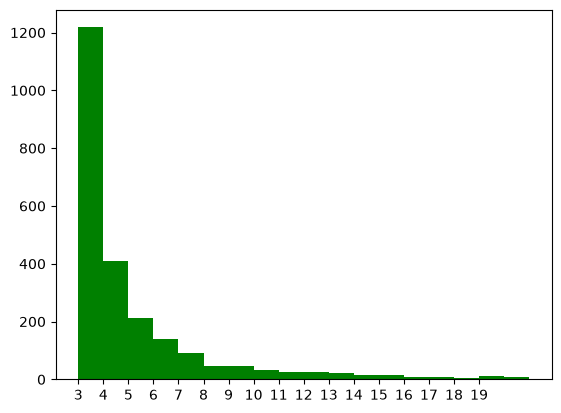

In [85]:


import numpy as np
import matplotlib.pyplot as plt
dist2 = {k: v for k, v in sorted(dist.items(), key=lambda item: item[0]) if 20 >k > 1}



pos = np.arange(len(dist2.keys()))
width = 1    # gives histogram aspect to the bar diagram

ax = plt.axes()
ax.set_xticks(pos + (width / 2))
ax.set_xticklabels(dist2.keys())

plt.bar(dist2.keys(), dist2.values(), width, color='g')
#                           
plt.show()

,PROMPTTYPE,Index,Requirement,Ground Truth,Atomic Proposition,Original Response,Response,Equivalent,Datasource,LLM Type,Temperature
